In [50]:

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten


In [51]:

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/datasets/prabhavsinghal/neu-data/NEU-DET/train/images',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/datasets/prabhavsinghal/neu-data/NEU-DET/validation/images',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (224, 224)
)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.


In [52]:
print(train_ds.class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [53]:
from tensorflow.keras.applications import EfficientNetB0

In [54]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [55]:
base_model.trainable = False

In [56]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [57]:
model = Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(6, activation='softmax')

])

In [58]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [59]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [60]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 279ms/step - accuracy: 0.8826 - loss: 0.4093 - val_accuracy: 0.9417 - val_loss: 0.1573
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9861 - loss: 0.0589 - val_accuracy: 0.9667 - val_loss: 0.1191
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9951 - loss: 0.0323 - val_accuracy: 0.9750 - val_loss: 0.0737
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9972 - loss: 0.0246 - val_accuracy: 0.9917 - val_loss: 0.0377
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9931 - loss: 0.0207 - val_accuracy: 0.9861 - val_loss: 0.0394
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9986 - loss: 0.0164 - val_accuracy: 0.9778 - val_loss: 0.0768
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9937 - loss: 0.0234 - val_accuracy: 0.9806 - val_loss: 0.0549
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9979 - loss: 0.0097 - val_accuracy: 0.9889 -

In [63]:


import matplotlib.pyplot as plt

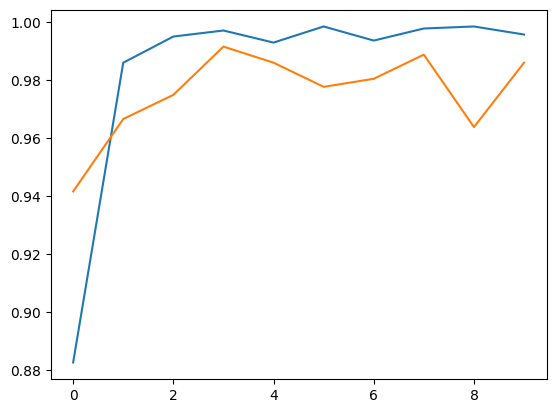

In [65]:


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

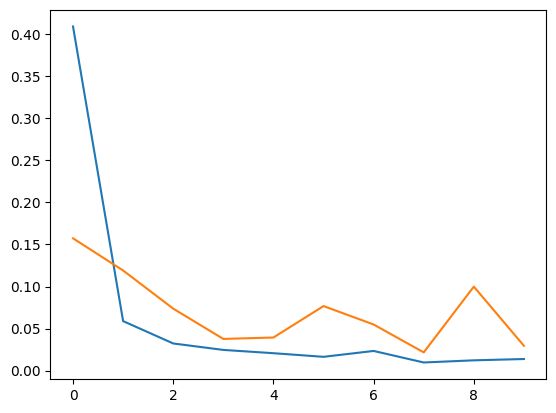

In [66]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [86]:
import cv2

In [87]:
test_image = cv2.imread('/kaggle/input/datasets/prabhavsinghal/neu-data/NEU-DET/validation/images/pitted_surface/pitted_surface_244.jpg')

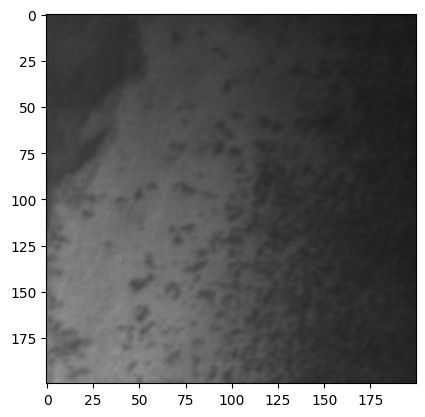

In [88]:
plt.imshow(test_image)

In [89]:
test_image = cv2.resize(

    test_image,

    (224,224)

)

In [90]:
test_image = np.array(test_image)

test_image = test_image / 255.0

In [91]:
test_input = test_image.reshape((1,224,224,3))

In [92]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


array([[0.00831332, 0.0343178 , 0.00986776, 0.9298885 , 0.0012886 ,
        0.01632401]], dtype=float32)

In [93]:
prediction = model.predict(test_input)

class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
]

pred_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction)

print("Class:", pred_class)
print("Confidence:", confidence*100,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Class: pitted_surface
Confidence: 92.988846 %


In [85]:
model.save("neu_defect_classifier.keras")